In [3]:
!pip install opencv-python psutil pynvml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 3.5 MB/s eta 0:00:00


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import psutil
import os

# GPU monitoring
try:
    import pynvml
    pynvml.nvmlInit()
    GPU_AVAILABLE = True
except:
    GPU_AVAILABLE = False

process = psutil.Process(os.getpid())

In [5]:
def get_cpu_memory_mb():
    return process.memory_info().rss / (1024 ** 2)


def get_gpu_memory_mb():
    if not GPU_AVAILABLE:
        return 0

    handle = pynvml.nvmlDeviceGetHandleByIndex(0)
    info = pynvml.nvmlDeviceGetMemoryInfo(handle)

    return info.used / (1024 ** 2)

Saving Whisk_6438decd43af638858247802b8b8e15bdr.png to Whisk_6438decd43af638858247802b8b8e15bdr.png


(np.float64(-0.5), np.float64(767.5), np.float64(1343.5), np.float64(-0.5))

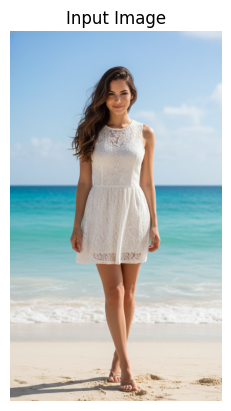

In [6]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = cv2.imread(image_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image_rgb)
plt.title("Input Image")
plt.axis('off')

In [7]:
def hog_svm_detection(image):

    hog = cv2.HOGDescriptor()

    hog.setSVMDetector(
        cv2.HOGDescriptor_getDefaultPeopleDetector()
    )

    start_time = time.time()

    cpu_before = get_cpu_memory_mb()
    gpu_before = get_gpu_memory_mb()

    boxes, weights = hog.detectMultiScale(
        image,
        winStride=(8,8),
        padding=(8,8),
        scale=1.05
    )

    cpu_after = get_cpu_memory_mb()
    gpu_after = get_gpu_memory_mb()

    end_time = time.time()

    time_taken = end_time - start_time

    cpu_used = cpu_after - cpu_before
    gpu_used = gpu_after - gpu_before

    result = image.copy()

    for (x,y,w,h) in boxes:
        cv2.rectangle(result, (x,y), (x+w,y+h),
                      (0,255,0), 2)

    return result, time_taken, cpu_used, gpu_used

In [8]:
def haar_detection(image):

    cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades +
        "haarcascade_frontalface_default.xml"
    )

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    start_time = time.time()

    cpu_before = get_cpu_memory_mb()
    gpu_before = get_gpu_memory_mb()

    faces = cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30,30)
    )

    cpu_after = get_cpu_memory_mb()
    gpu_after = get_gpu_memory_mb()

    end_time = time.time()

    time_taken = end_time - start_time

    cpu_used = cpu_after - cpu_before
    gpu_used = gpu_after - gpu_before

    result = image.copy()

    for (x,y,w,h) in faces:
        cv2.rectangle(result,
                      (x,y),
                      (x+w,y+h),
                      (255,0,0),
                      2)

    return result, time_taken, cpu_used, gpu_used

HOG + SVM Performance:
Time taken: 0.7736 sec
CPU memory used: 17.05 MB
GPU memory used: 0.00 MB


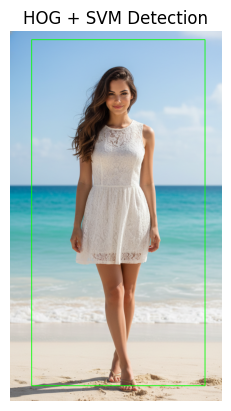

In [9]:
hog_result, hog_time, hog_cpu, hog_gpu = hog_svm_detection(image)

plt.imshow(cv2.cvtColor(hog_result, cv2.COLOR_BGR2RGB))
plt.title("HOG + SVM Detection")
plt.axis('off')

print("HOG + SVM Performance:")
print(f"Time taken: {hog_time:.4f} sec")
print(f"CPU memory used: {hog_cpu:.2f} MB")
print(f"GPU memory used: {hog_gpu:.2f} MB")


Haar Cascade Performance:
Time taken: 0.4495 sec
CPU memory used: 33.81 MB
GPU memory used: 0.00 MB


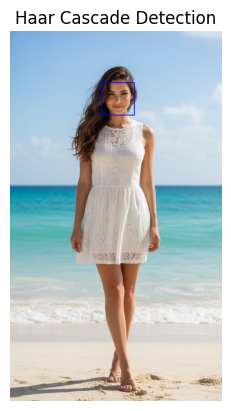

In [10]:
haar_result, haar_time, haar_cpu, haar_gpu = haar_detection(image)

plt.imshow(cv2.cvtColor(haar_result, cv2.COLOR_BGR2RGB))
plt.title("Haar Cascade Detection")
plt.axis('off')

print("Haar Cascade Performance:")
print(f"Time taken: {haar_time:.4f} sec")
print(f"CPU memory used: {haar_cpu:.2f} MB")
print(f"GPU memory used: {haar_gpu:.2f} MB")